<a href="https://colab.research.google.com/github/CWill22/NeuroHW12/blob/main/Trees%2C_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# In Depth: Decision Trees and Random Forests

Previously we have looked in depth at a simple generative classifier (naive Bayes; see [In Depth: Naive Bayes Classification](05.05-Naive-Bayes.ipynb)) and a powerful discriminative classifier (support vector machines; see [In-Depth: Support Vector Machines](05.07-Support-Vector-Machines.ipynb)).
Here we'll take a look at another powerful algorithm: a nonparametric algorithm called *random forests*.
Random forests are an example of an *ensemble* method, meaning one that relies on aggregating the results of a set of simpler estimators.
The somewhat surprising result with such ensemble methods is that the sum can be greater than the parts: that is, the predictive accuracy of a majority vote among a number of estimators can end up being better than that of any of the individual estimators doing the voting!
We will see examples of this in the following sections.

We begin with the standard imports:

In [49]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use Seaborn to set the whitegrid style
sns.set_style("whitegrid")


In [50]:
"""
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Import Seaborn
plt.style.use('seaborn-whitegrid')
"""

"\n%matplotlib inline\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns  # Import Seaborn\nplt.style.use('seaborn-whitegrid')\n"

## Motivating Random Forests: Decision Trees

Random forests are an example of an ensemble learner built on decision trees.
For this reason, we'll start by discussing decision trees themselves.

Decision trees are extremely intuitive ways to classify or label objects: you simply ask a series of questions designed to zero in on the classification.
For example, if you wanted to build a decision tree to classify animals you come across while on a hike, you might construct the one shown in the following figure.

![](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/images/05.08-decision-tree.png?raw=1)
[figure source in Appendix](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/06.00-Figure-Code.ipynb#Decision-Tree-Example)

The binary splitting makes this extremely efficient: in a well-constructed tree, each question will cut the number of options by approximately half, very quickly narrowing the options even among a large number of classes.
The trick, of course, comes in deciding which questions to ask at each step.
In machine learning implementations of decision trees, the questions generally take the form of axis-aligned splits in the data: that is, each node in the tree splits the data into two groups using a cutoff value within one of the features.
Let's now look at an example of this.

### Creating a Decision Tree

Consider the following two-dimensional data, which has one of four class labels (see the following figure):

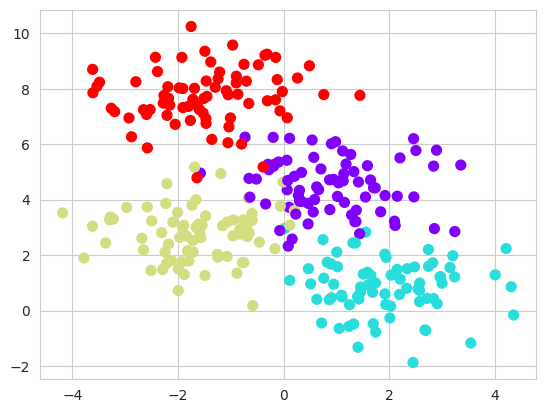

In [51]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

A simple decision tree built on this data will iteratively split the data along one or the other axis according to some quantitative criterion, and at each level assign the label of the new region according to a majority vote of points within it.
The following figure presents a visualization of the first four levels of a decision tree classifier for this data.

![](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/images/05.08-decision-tree-levels.png?raw=1)
[figure source in Appendix](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/06.00-Figure-Code.ipynb#Decision-Tree-Levels)

Notice that after the first split, every point in the upper branch remains unchanged, so there is no need to further subdivide this branch.
Except for nodes that contain all of one color, at each level *every* region is again split along one of the two features.

This process of fitting a decision tree to our data can be done in Scikit-Learn with the ``DecisionTreeClassifier`` estimator:

In [52]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier().fit(X, y)

Let's write a utility function to help us visualize the output of the classifier:

In [53]:
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

Now we can examine what the decision tree classification looks like (see the following figure):

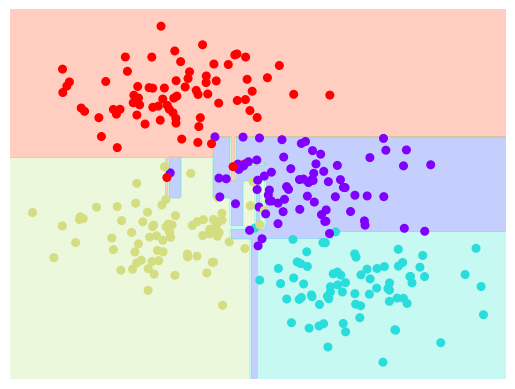

In [54]:
visualize_classifier(DecisionTreeClassifier(), X, y)

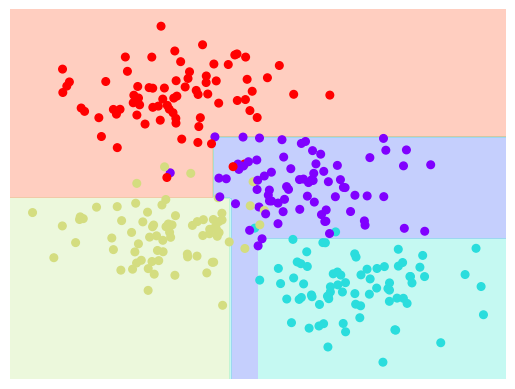

In [55]:
visualize_classifier(DecisionTreeClassifier(max_depth = 4), X, y)

If you're running this notebook live, you can use the helper script included in the online [appendix](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/06.00-Figure-Code.ipynb#Helper-Code) to bring up an interactive visualization of the decision tree building process:

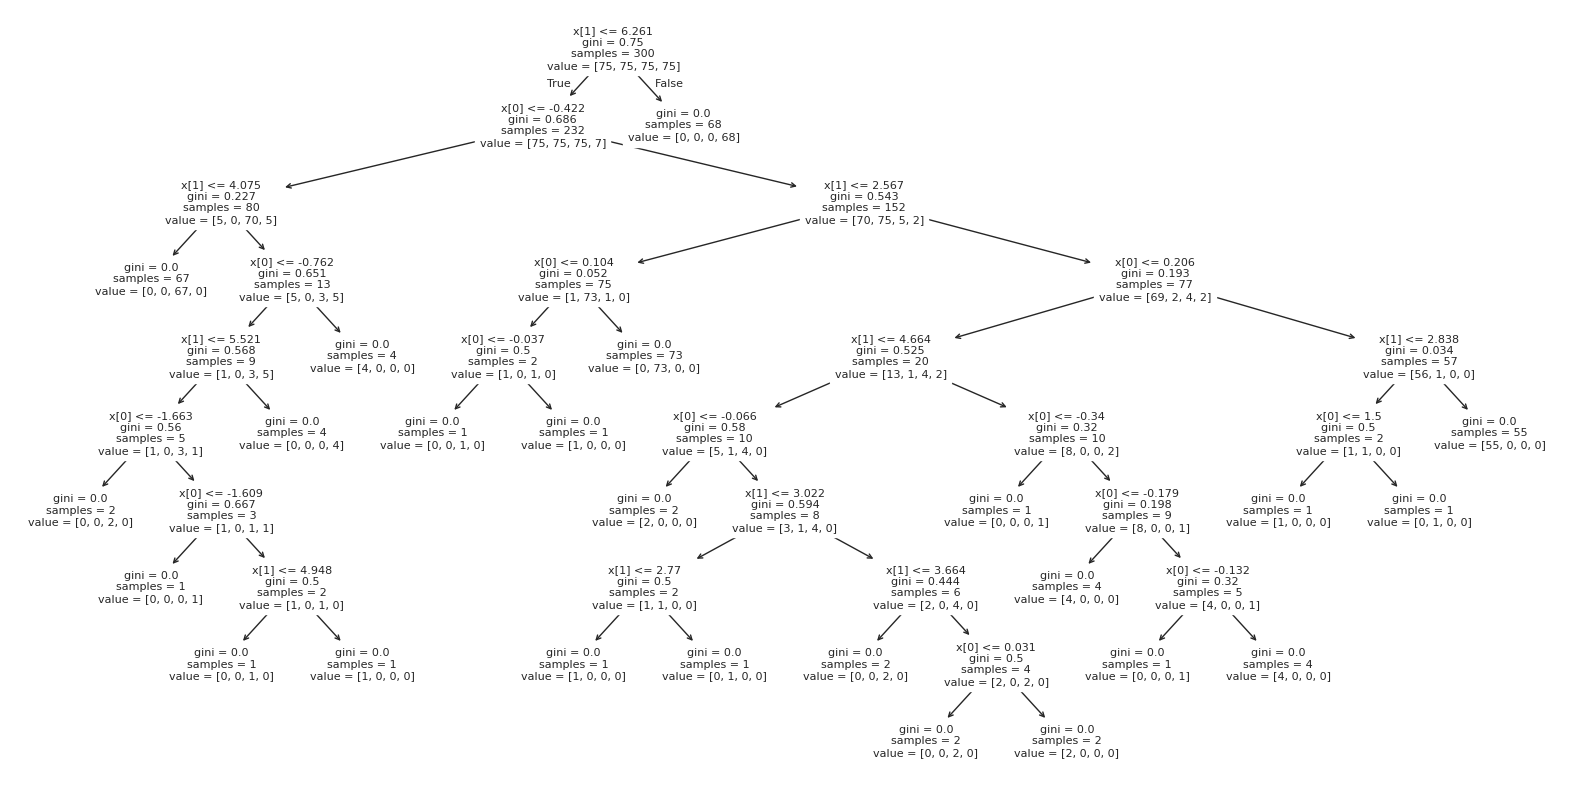

In [56]:
from sklearn.tree import plot_tree
plt.figure(figsize = (20, 10))
plot_tree(tree);

In [57]:
# helpers_05_08 is found in the online appendix
# import helpers_05_08
# helpers_05_08.plot_tree_interactive(X, y);

Notice that as the depth increases, we tend to get very strangely shaped classification regions; for example, at a depth of five, there is a tall and skinny purple region between the yellow and blue regions.
It's clear that this is less a result of the true, intrinsic data distribution, and more a result of the particular sampling or noise properties of the data.
That is, this decision tree, even at only five levels deep, is clearly overfitting our data.

In [58]:
tree.feature_importances_

array([0.3425493, 0.6574507])

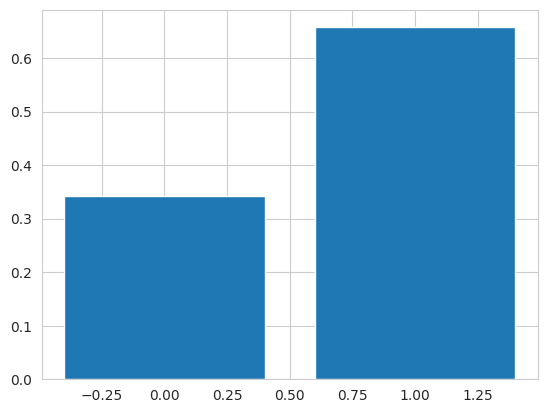

In [59]:
plt.bar([0, 1], tree.feature_importances_);

### Decision Trees and Overfitting

Such overfitting turns out to be a general property of decision trees: it is very easy to go too deep in the tree, and thus to fit details of the particular data rather than the overall properties of the distributions it is drawn from.
Another way to see this overfitting is to look at models trained on different subsets of the data—for example, in this figure we train two different trees, each on half of the original data.

![](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/images/05.08-decision-tree-overfitting.png?raw=1)
[figure source in Appendix](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/06.00-Figure-Code.ipynb#Decision-Tree-Overfitting)

It is clear that in some places the two trees produce consistent results (e.g., in the four corners), while in other places the two trees give very different classifications (e.g., in the regions between any two clusters).
The key observation is that the inconsistencies tend to happen where the classification is less certain, and thus by using information from *both* of these trees, we might come up with a better result!

If you are running this notebook live, the following function will allow you to interactively display the fits of trees trained on a random subset of the data:

In [60]:
# helpers_05_08 is found in the online appendix
# import helpers_05_08
# helpers_05_08.randomized_tree_interactive(X, y)

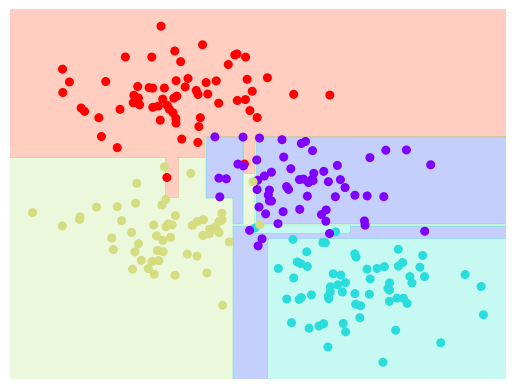

In [61]:
random_inds = np.random.choice(range(len(X)), int(0.8 * len(X)), replace = False)
Xs, ys = X[random_inds], y[random_inds]
visualize_classifier(DecisionTreeClassifier(), Xs, ys)

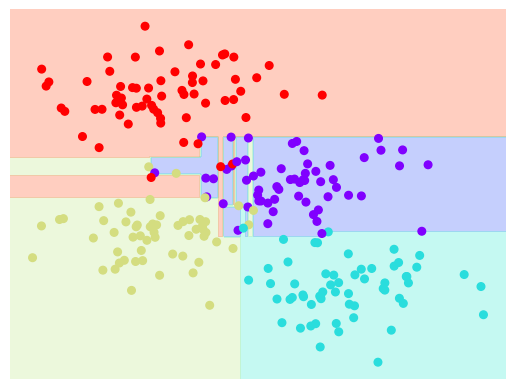

In [62]:
random_inds = np.random.choice(range(len(X)), int(0.8 * len(X)), replace = False)
Xs, ys = X[random_inds], y[random_inds]
visualize_classifier(DecisionTreeClassifier(), Xs, ys)

Just as using information from two trees improves our results, we might expect that using information from many trees would improve our results even further.

## Ensembles of Estimators: Random Forests

This notion—that multiple overfitting estimators can be combined to reduce the effect of this overfitting—is what underlies an ensemble method called *bagging*.
Bagging makes use of an ensemble (a grab bag, perhaps) of parallel estimators, each of which overfits the data, and averages the results to find a better classification.
An ensemble of randomized decision trees is known as a *random forest*.

This type of bagging classification can be done manually using Scikit-Learn's `BaggingClassifier` meta-estimator, as shown here (see the following figure):

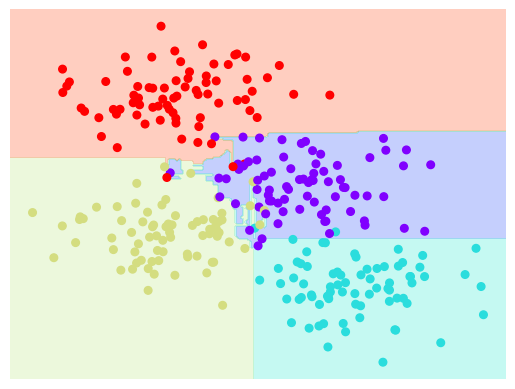

In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier()
bag = BaggingClassifier(tree, n_estimators=100, max_samples=0.8,
                        random_state=1)

bag.fit(X, y)
visualize_classifier(bag, X, y)

In this example, we have randomized the data by fitting each estimator with a random subset of 80% of the training points.
In practice, decision trees are more effectively randomized by injecting some stochasticity in how the splits are chosen: this way all the data contributes to the fit each time, but the results of the fit still have the desired randomness.
For example, when determining which feature to split on, the randomized tree might select from among the top several features.
You can read more technical details about these randomization strategies in the [Scikit-Learn documentation](http://scikit-learn.org/stable/modules/ensemble.html#forest) and references within.

In Scikit-Learn, such an optimized ensemble of randomized decision trees is implemented in the `RandomForestClassifier` estimator, which takes care of all the randomization automatically.
All you need to do is select a number of estimators, and it will very quickly—in parallel, if desired—fit the ensemble of trees (see the following figure):

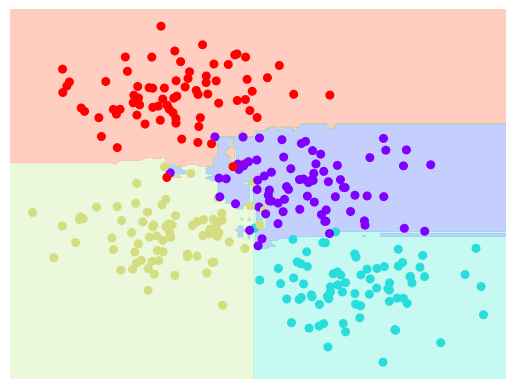

In [64]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)
visualize_classifier(model, X, y);

We see that by averaging over 100 randomly perturbed models, we end up with an overall model that is much closer to our intuition about how the parameter space should be split.

## Random Forest Regression

In the previous section we considered random forests within the context of classification.
Random forests can also be made to work in the case of regression (that is, with continuous rather than categorical variables). The estimator to use for this is the `RandomForestRegressor`, and the syntax is very similar to what we saw earlier.

Consider the following data, drawn from the combination of a fast and slow oscillation (see the following figure):

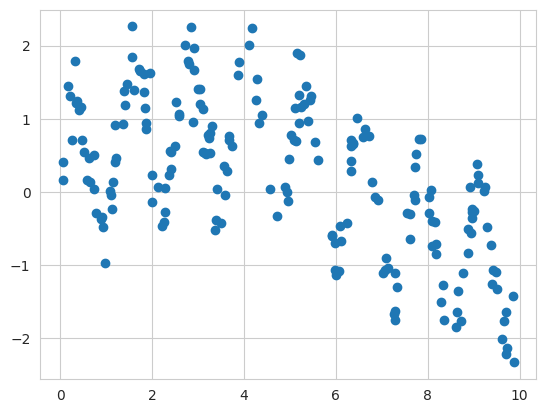

In [65]:
rng = np.random.RandomState(42)
x = 10 * rng.rand(200)

def model(x, sigma=0.3):
    fast_oscillation = np.sin(5 * x)
    slow_oscillation = np.sin(0.5 * x)
    noise = sigma * rng.randn(len(x))

    return slow_oscillation + fast_oscillation + noise

y = model(x)
plt.scatter(x, y);

Using the random forest regressor, we can find the best-fit curve as follows (see the following figure):

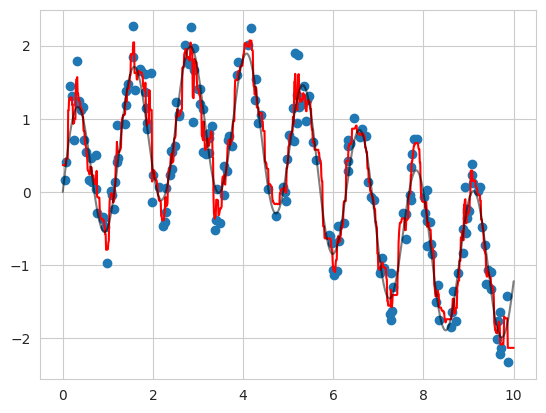

In [66]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor(200)
forest.fit(x[:, None], y)

xfit = np.linspace(0, 10, 1000)
yfit = forest.predict(xfit[:, None])
ytrue = model(xfit, sigma=0)

plt.scatter(x, y)
plt.plot(xfit, yfit, '-r');
plt.plot(xfit, ytrue, '-k', alpha=0.5);

Here the true model is shown in the smooth gray curve, while the random forest model is shown by the jagged red curve.
The nonparametric random forest model is flexible enough to fit the multiperiod data, without us needing to specifying a multi-period model!

## Example: Random Forest for Classifying Digits

In Chapter 38 we worked through an example using the digits dataset included with Scikit-Learn.
Let's use that again here to see how the random forest classifier can be applied in this context:

In [67]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

To remind us what we're looking at, we'll visualize the first few data points (see the following figure):

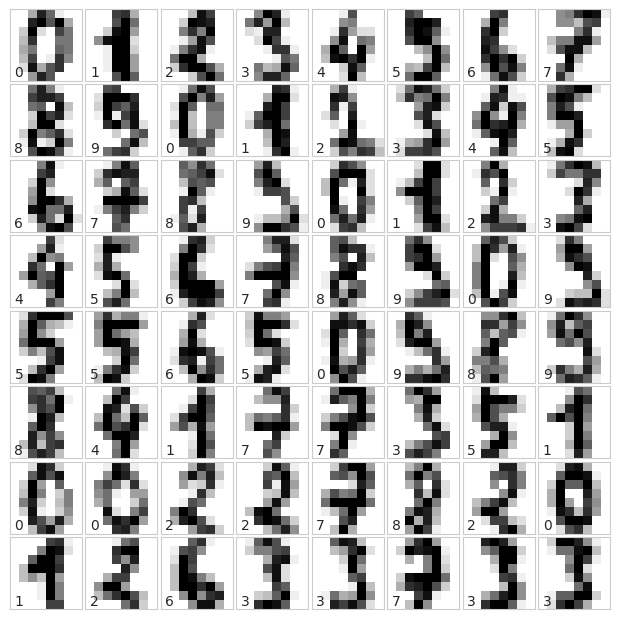

In [68]:
# set up the figure
fig = plt.figure(figsize=(6, 6))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# plot the digits: each image is 8x8 pixels
for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')

    # label the image with the target value
    ax.text(0, 7, str(digits.target[i]))

We can classify the digits using a random forest as follows:

In [69]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target,
                                                random_state=0)
model = RandomForestClassifier(n_estimators=1000)
model.fit(Xtrain, ytrain)
ypred = model.predict(Xtest)

Let's look at the classification report for this classifier:

In [70]:
from sklearn import metrics
print(metrics.classification_report(ypred, ytest))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        38
           1       0.98      0.98      0.98        43
           2       0.95      1.00      0.98        42
           3       0.98      0.96      0.97        46
           4       0.97      1.00      0.99        37
           5       0.98      0.96      0.97        49
           6       1.00      1.00      1.00        52
           7       1.00      0.96      0.98        50
           8       0.94      0.98      0.96        46
           9       0.98      0.98      0.98        47

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



And for good measure, plot the confusion matrix (see the following figure):

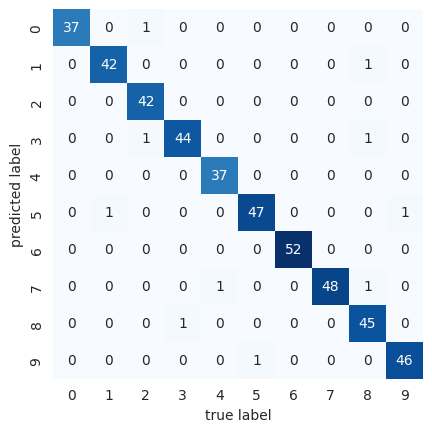

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
mat = confusion_matrix(ytest, ypred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d',
            cbar=False, cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label');

We find that a simple, untuned random forest results in a quite accurate classification of the digits data.

## Summary

This chapter provided a brief introduction to the concept of ensemble estimators, and in particular the random forest, an ensemble of randomized decision trees.
Random forests are a powerful method with several advantages:

- Both training and prediction are very fast, because of the simplicity of the underlying decision trees. In addition, both tasks can be straightforwardly parallelized, because the individual trees are entirely independent entities.
- The multiple trees allow for a probabilistic classification: a majority vote among estimators gives an estimate of the probability (accessed in Scikit-Learn with the `predict_proba` method).
- The nonparametric model is extremely flexible and can thus perform well on tasks that are underfit by other estimators.

A primary disadvantage of random forests is that the results are not easily interpretable: that is, if you would like to draw conclusions about the *meaning* of the classification model, random forests may not be the best choice.

# Homework

#### Problem 1.
Load the Iris dataset from sklearn,
```
from sklearn.datasets import load_iris
```
Following the example above, train a random forest classifier on the train sample and show accuracy on the test sample. Estimate and make a bar-plot of feature importances and interpret the ranking.

#### Problem 2.
Estimate and make a bar-plot of feature importances for the `digits` example above and interpret the ranking (just one/two lines for plotting is enough).

#### Problem 3.
Develop a random forest model to solve the classification problem of Project 3 using extracted input features of the LFP signal. Estimate and make a bar-plot of feature importances and interpret the results.

Test Set Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



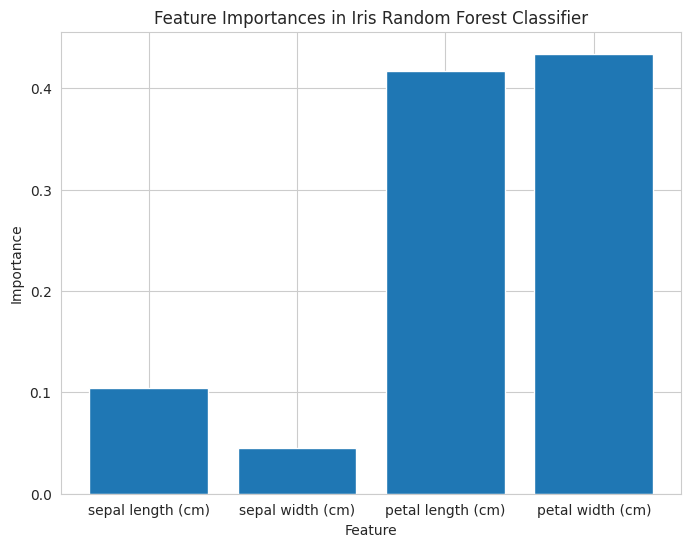

In [72]:
# problem 1
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Load the iris data
iris = load_iris()
X, y = iris.data, iris.target

# Split the data into a training and test sample (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# Train a Random Forest classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

# Evaluate the model
acc = accuracy_score(y_test, y_pred)
print("Test Set Accuracy: {:.2f}%".format(acc * 100))
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=iris.target_names))

# Plot feature importances
importances = rf_clf.feature_importances_
feature_names = iris.feature_names

plt.figure(figsize=(8, 6))
plt.bar(feature_names, importances)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Iris Random Forest Classifier")
plt.show()


In problem 1, the rankings show that the petal length and petal width are the best features to use if we wanted to classify the samples. This is because they separate the dataset the most.

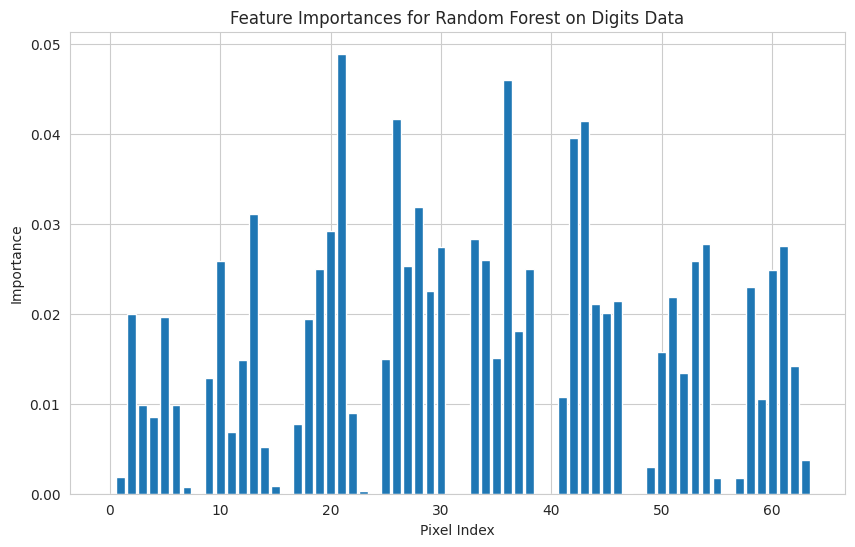

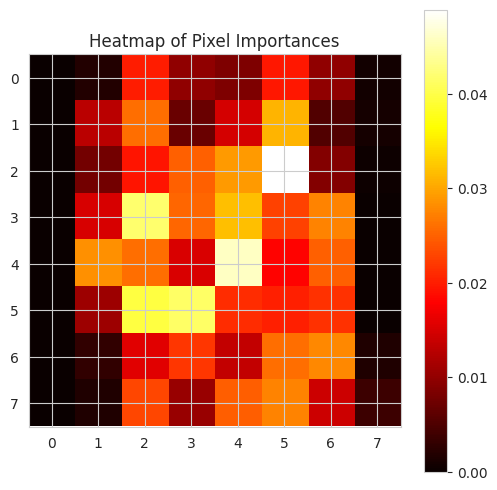

In [73]:
#problem 2
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Load the digits data
digits = load_digits()
X, y = digits.data, digits.target

# Train a Random Forest classifier
rf_digits = RandomForestClassifier(n_estimators=100, random_state=42)
rf_digits.fit(X, y)

# Get feature importances
importances = rf_digits.feature_importances_

# Option 1: Simple bar plot over pixel indices (one line per feature)
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances)
plt.xlabel("Pixel Index")
plt.ylabel("Importance")
plt.title("Feature Importances for Random Forest on Digits Data")
plt.show()

# Option 2: Reshape the importances to an 8x8 image and plot as a heatmap
plt.figure(figsize=(6, 6))
plt.imshow(importances.reshape(8, 8), cmap='hot', interpolation='nearest')
plt.title("Heatmap of Pixel Importances")
plt.colorbar()
plt.show()


For problem 2, we are shown the importance of looking at each pixel in the image in determining the drawn number. Some pixel locations, like the ones towards the center and slightly to the right, seems to be the best ones, as what that pixel contains gives us a good clue on what numbers it could be.

In [76]:
# problem 3- data loading
import h5py
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.signal import welch
from sklearn.preprocessing import StandardScaler

# List of HDF5 file paths (adjust if necessary)
file_paths = ['Rat08-20130711_017.h5', 'Part1SubjectHB10.h5', 'Part2SubjectHB13.h5']

# Dictionary to accumulate LFP recordings for each state (e.g. NREM, WAKE)
lfp = {}
for fp in file_paths:
    with h5py.File(fp, 'r') as f:
        # The keys in each file represent the states (e.g., 'NREM' and 'WAKE')
        for state in f.keys():
            if state not in lfp:
                lfp[state] = []
            group = f[state]
            # Loop over segment keys within the group (assumed to be string labels like "1", "2", ...)
            for seg_id in group.keys():
                # Convert the segment data to a float NumPy array
                lfp[state].append(group[seg_id][()].astype(float))

print("States loaded:", list(lfp.keys()))

# Set parameters for segmentation and feature extraction
fs = 1000                # sampling frequency (Hz) – adjust if needed
clip_length_sec = 5      # clip duration in seconds
clip_length_samples = fs * clip_length_sec

def segment_signal(signal, clip_length_samples):
    """
    Segments a 1D signal into non-overlapping clips.
    """
    clips = []
    n_samples = len(signal)
    for start in range(0, n_samples - clip_length_samples + 1, clip_length_samples):
        clips.append(signal[start:start+clip_length_samples])
    return clips

def extract_features(clip, fs):
    """
    Extracts a set of time-domain and frequency-domain features from a signal clip.
    Features:
      - Mean, Standard Deviation, Skewness, Kurtosis (time-domain)
      - Total power, and relative power in Delta (0.5-4 Hz), Theta (4-8 Hz),
        Alpha (8-12 Hz), Beta (12-30 Hz) bands (frequency-domain)
    """
    # Time-domain features
    mean_val = np.mean(clip)
    std_val = np.std(clip)
    skew_val = skew(clip)
    kurt_val = kurtosis(clip)

    # Frequency-domain: compute power spectral density (PSD) with Welch’s method
    f_vals, pxx = welch(clip, fs=fs, nperseg=fs//2)
    total_power = np.sum(pxx) + 1e-9  # add epsilon to avoid division by zero

    # Function to compute power in a specified frequency band
    def band_power(low, high):
        idx = (f_vals >= low) & (f_vals < high)
        return np.sum(pxx[idx])

    delta_power = band_power(0.5, 4)
    theta_power = band_power(4, 8)
    alpha_power = band_power(8, 12)
    beta_power  = band_power(12, 30)

    # Relative band powers
    delta_rel = delta_power / total_power
    theta_rel = theta_power / total_power
    alpha_rel = alpha_power / total_power
    beta_rel  = beta_power  / total_power

    # Concatenate features into a single vector
    features = np.array([
        mean_val, std_val, skew_val, kurt_val,
        total_power, delta_rel, theta_rel, alpha_rel, beta_rel
    ])

    return features

# Build the feature dataset and label vector
X_all = []
y_all = []
# Define a mapping for state labels: 0 for NREM, 1 for WAKE.
state_label = {'NREM': 0, 'WAKE': 1}

for state, segments in lfp.items():
    # Process each recording segment for the state
    for signal in segments:
        # (If necessary: if signal is multidimensional, select the appropriate channel)
        if signal.ndim > 1:
            signal = signal.flatten()
        # Segment the continuous signal into fixed-length clips
        clips = segment_signal(signal, clip_length_samples)
        print("State {}: {} clips extracted.".format(state, len(clips)))

        # Extract features from each clip and append appropriate labels
        for clip in clips:
            feat = extract_features(clip, fs)
            X_all.append(feat)
            # Convert state name to uppercase to match our mapping keys.
            if state.upper() in state_label:
                y_all.append(state_label[state.upper()])
            else:
                # Skip states that are not defined (if any)
                continue

X_all = np.array(X_all)
y_all = np.array(y_all)
print("Total samples:", X_all.shape[0], ", Feature dimension:", X_all.shape[1])

# Normalize the features using z-score normalization
scaler = StandardScaler()
X_all_norm = scaler.fit_transform(X_all)


States loaded: ['NREM', 'WAKE']
State NREM: 22 clips extracted.
State NREM: 53 clips extracted.
State NREM: 14 clips extracted.
State NREM: 10 clips extracted.
State NREM: 30 clips extracted.
State NREM: 12 clips extracted.
State NREM: 13 clips extracted.
State NREM: 40 clips extracted.
State NREM: 38 clips extracted.
State NREM: 35 clips extracted.
State NREM: 21 clips extracted.
State NREM: 12 clips extracted.
State NREM: 21 clips extracted.
State NREM: 18 clips extracted.
State NREM: 10 clips extracted.
State NREM: 29 clips extracted.
State NREM: 33 clips extracted.
State NREM: 35 clips extracted.
State NREM: 30 clips extracted.
State NREM: 38 clips extracted.
State NREM: 19 clips extracted.
State NREM: 38 clips extracted.
State NREM: 22 clips extracted.
State NREM: 44 clips extracted.
State NREM: 53 clips extracted.
State NREM: 10 clips extracted.
State NREM: 104 clips extracted.
State NREM: 15 clips extracted.
State NREM: 20 clips extracted.
State NREM: 13 clips extracted.
State N

Total samples: 6437, Feature vector length: 9
Test Set Accuracy: 91.85%

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.86      0.88       458
           1       0.93      0.95      0.94       830

    accuracy                           0.92      1288
   macro avg       0.91      0.91      0.91      1288
weighted avg       0.92      0.92      0.92      1288



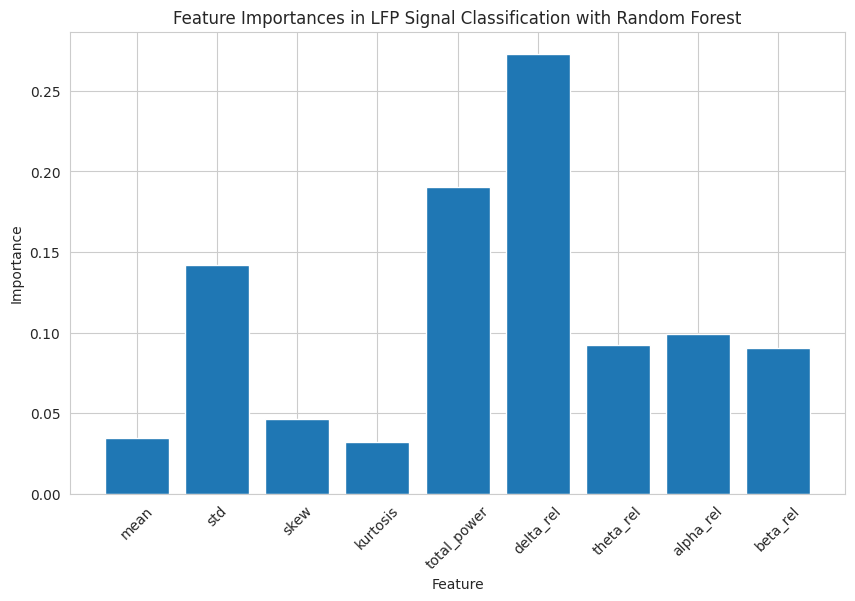

In [77]:
# problem 3
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Print dataset dimensions
print("Total samples: {}, Feature vector length: {}".format(X_all_norm.shape[0], X_all_norm.shape[1]))

# Split the dataset into training and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_all_norm, y_all, test_size=0.2, random_state=42)

# Train a Random Forest classifier on the extracted LFP features
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Set Accuracy: {:.2f}%".format(accuracy * 100))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Define feature names corresponding to the extracted features
feature_names = ['mean', 'std', 'skew', 'kurtosis',
                 'total_power', 'delta_rel', 'theta_rel', 'alpha_rel', 'beta_rel']

# Plot feature importances as determined by the Random Forest
importances = rf_classifier.feature_importances_
plt.figure(figsize=(10, 6))
plt.bar(feature_names, importances)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in LFP Signal Classification with Random Forest")
plt.xticks(rotation=45)
plt.show()


In problem 3, we looked at the different statistics of the dataset and how well each one could classify the data, and it turns out that the standard deviation, total power, and reletive delta of the dataset were the most useful.